# Closure strength

I want to measure how decisively a story lands. Some films finish with the final bell, the hero bruised but standing, music swelling. You feel the ending the moment it arrives. Other films just sort of trail off. The villain is still out there. Someone monologues about a dream. Credits roll and you're not quite sure the story is actually over.

Rocky and No Country for Old Men live at these two poles for me, and I want a number that can tell them apart across all 1,627 scripts.

My first instinct was simple: take the last 10% of the script, look at its sentiment, and see how far above (or below) the film's own average it lands. If the ending sits above the baseline, the film closes on an emotional high. If it sits below, it closes low...either tragically, or because the story never really lands at all.

But you (Thiago) suggested something different. Maybe closure isn't about *where* the ending sits, but *how hard it moves* in the final moments. A "punchy ending," in your words. Instead of comparing the last 10% to the whole film, you would measure the slope of the last 20%, so how steep the emotional line is as the credits approach.

I honestly didn't know which one is right, so I'm going to compute both and see which one matches how Rocky and No Country actually feel.

One thing worth mentioning: I'm pulling everything from the arc data I already generated, and that data is already z-scored per film. Which means each film is normalized against its own emotional volatility. A wild swingy film and a flat quiet film end up on the same scale. No new model runs needed. I can answer this with what I already have.

## 1. Setup

Nothing fancy here. I just point at the folder where the per-film arc files already live, and load up the list.

In [9]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ARCS_DIR = Path('../docs/thesis-outputs/arcs')
OUT_DIR = Path('../docs/thesis-outputs')

arc_files = sorted(ARCS_DIR.glob('*_arc.json'))
print(f'{len(arc_files)} arc files')

1627 arc files


## 2. The two metrics

Each arc file has a list of points along the film's length, from position 0.05 (the very beginning) to 0.975 (right before the credits). Each point has a z-score. That's the sentiment at that moment, measured in "how far from this film's own average."

That normalization matters a lot. A z-score of +1 means "one standard deviation above this film's baseline," so it means the same thing for a sleepy drama as it does for a chaotic action movie. Everything gets compared on its own terms.

From that, I can compute both metrics in a couple of lines:

- **Level**: average the z-scores inside the final 10% of the film. If the number is positive, the ending sits above the film's own average. Negative means it lands below.
- **Slope**: fit a straight line through the final 20% and read off how steep it is. A steep upward line means the film is climbing hard as it ends. A steep downward line means it's crashing. (your idea)

Neither of these requires me to re-run the sentiment model thank god.

In [8]:
def load_main_arc(path):
    with open(path) as f:
        data = json.load(f)
    pts = data['main_arc']
    pos = np.array([p['position'] for p in pts])
    z = np.array([p['z_score'] for p in pts])
    return data, pos, z


def closure_level(pos, z, window=0.10):
    """Mean z-score inside the final `window` of the arc."""
    mask = pos >= (1.0 - window)
    return float(z[mask].mean()) if mask.any() else np.nan


def closure_slope(pos, z, window=0.20):
    """Linear slope of z-score over the final `window` of the arc."""
    mask = pos >= (1.0 - window)
    if mask.sum() < 2:
        return np.nan
    slope, _ = np.polyfit(pos[mask], z[mask], 1)
    return float(slope)

## 3. The sanity check: Rocky vs. No Country

Before I trust either metric on 1,627 films, I want to see them agree with my gut on the two films I already have opinions about.

A small technicality: the original Rocky (1976) isn't in my corpus, so I'm using Rocky Balboa (2006) instead. It's the closest match I have — aging fighter goes the distance, loses the fight, keeps his dignity. Structurally the same shape of ending.

Here's what I expect to see, honestly:

- **Rocky Balboa** should land high. The whole final stretch is the fight, the bell, the aftermath. If my metrics are any good, that final window should sit well above the film's own baseline.
- **No Country** should land flat or below. The climactic violence happens offscreen. The ending is Tommy Lee Jones recounting a dream. It's deliberately unresolved. A good closure metric should flag this as a film that doesn't land on a high.

Let me plot them side by side with the two final windows shaded, and see what the numbers say.

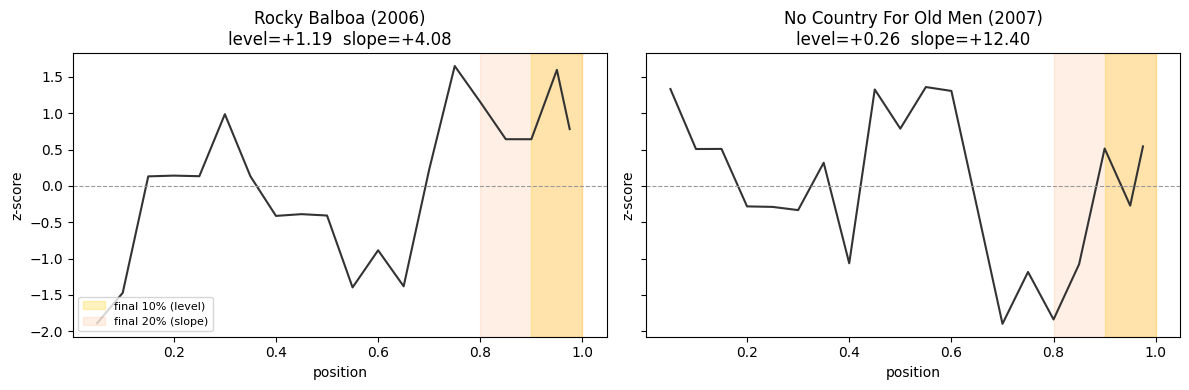

In [10]:
cases = ['rocky-balboa-2006', 'no-country-for-old-men-2007']

fig, axes = plt.subplots(1, len(cases), figsize=(12, 4), sharey=True)

for ax, slug in zip(axes, cases):
    path = ARCS_DIR / f'{slug}_arc.json'
    data, pos, z = load_main_arc(path)

    level = closure_level(pos, z)
    slope = closure_slope(pos, z)

    ax.plot(pos, z, color='#333', lw=1.5)
    ax.axhline(0, color='#999', lw=0.8, ls='--')
    ax.axvspan(0.9, 1.0, color='#ffcc00', alpha=0.25, label='final 10% (level)')
    ax.axvspan(0.8, 1.0, color='#ff6600', alpha=0.10, label='final 20% (slope)')
    ax.set_title(f"{data['title']} ({data['year']})\nlevel={level:+.2f}  slope={slope:+.2f}")
    ax.set_xlabel('position')
    ax.set_ylabel('z-score')

axes[0].legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.show()

Hmmm, I don't think your intuition holds up here, Thiago.

**Rocky Balboa** lives in positive territory for the entire final third. It climbs hard around 0.75, dips briefly, then closes near the top. The whole back half of the film *is* the resolution. Level comes out at +1.19, which is a rather big number. The ending sits more than a full standard deviation above this film's average. That matches the feeling.

**No Country** does something almost opposite. It crashes to nearly -2 around the 70% mark, then slowly crawls its way back toward zero, and finally pokes just barely above the baseline at the very end. Level comes out at +0.26, which is technically positive, but basically right at the film's average. Which feels right. The film doesn't really *land* anywhere; it just stops being unresolved.

The slope...well...tells the opposite story. No Country's slope is +12.4, Rocky's is only +4.1. By your metric, No Country has the "punchier" ending.

I don't think that's actually what closure means, though. No Country's slope is huge *because* it started so deep in a hole. It had to climb a long way just to reach zero. Rocky's slope is smaller because there was nowhere left to climb. The film was already up there. Slope, it turns out, doesn't measure "punchy" so much as "clawed its way out of a trough." I think those are different things.

So: level is doing what I want, slope isn't. But I don't want to commit based on one pair of films, so let me run both across the whole corpus and see how they behave at scale.

## 4. Corpus-wide computation

In [11]:
rows = []
for path in arc_files:
    try:
        data, pos, z = load_main_arc(path)
    except Exception as e:
        print(f'skip {path.name}: {e}')
        continue
    rows.append({
        'slug': data.get('slug', path.stem.replace('_arc', '')),
        'title': data.get('title'),
        'year': data.get('year'),
        'closure_level': closure_level(pos, z),
        'closure_slope': closure_slope(pos, z),
    })

closure = pd.DataFrame(rows)
print(closure.shape)
closure.describe()

(1627, 5)


,year,closure_level,closure_slope
count,1627.000000,1627.000000,1627.000000
mean,2006.708666,0.631491,6.899939
std,12.421213,0.888897,11.790077
min,1980.000000,-2.242036,-28.045897
25%,1996.500000,0.060840,-0.883535
50%,2010.000000,0.732977,7.250593
75%,2017.000000,1.300148,15.662294
max,2025.000000,2.581790,38.505930


Interesting. Here's my understanding of it in plain English:

The typical movie ends on a noticeably higher emotional note than its own average. Tthe median closure level is +0.73, which means half the films finish nearly three-quarters of a standard deviation above their own baseline mood. That's the Hollywood ending instinct showing up in my data: roughly three out of four films in the corpus lift at the end. But one in four doesn't. A full quarter of the films land flat or below their own baseline. I wouldn't call these edge cases per se, because they compose of hundreds of films that refuse that upward-lift convention (think of any tragedy that deliberatly withold catharsis). The range between these two extremes is enormous, spanning nearly five standard deviations from the most deflated ending (-2.24) to the most triumphant (+2.58), which tells me that how a film lands is one of the strongest ways it distinguishes itself from other films.

One thing worth remembering: the median release year in the corpus is 2010, so the data leans recent, which I think will matter later when I try to say anything about how endings have evolved over decades. The headline, though, is simple: most films end on a high, but the meaningful minority that doesn't is where the most interesting storytelling choices live.

## 5. Distributions and agreement

Do the two metrics tell the same story, or are they picking up different things? If they correlate tightly, slope is redundant. If not, they're measuring distinct aspects of how films end.

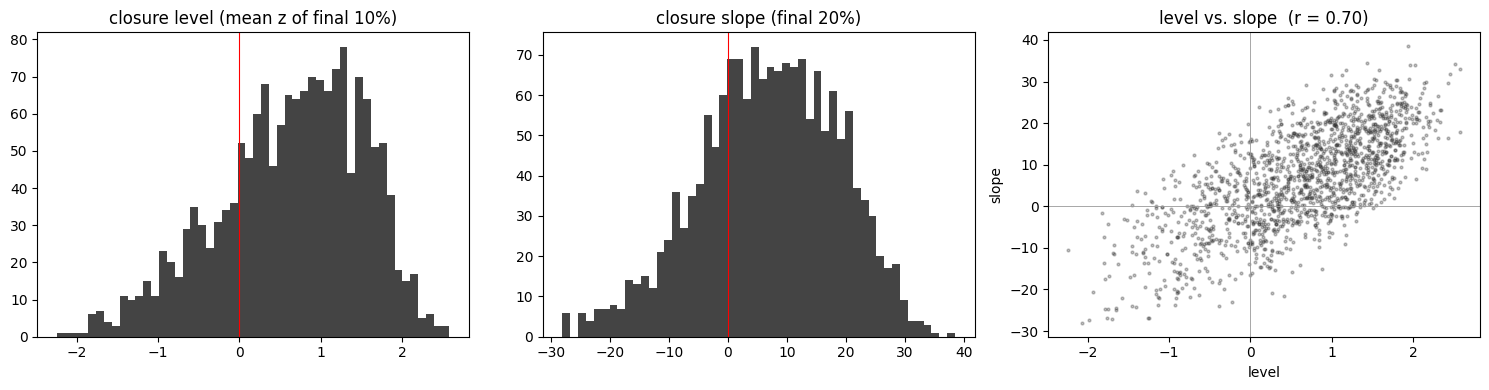

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(closure['closure_level'].dropna(), bins=50, color='#444')
axes[0].axvline(0, color='red', lw=0.8)
axes[0].set_title('closure level (mean z of final 10%)')

axes[1].hist(closure['closure_slope'].dropna(), bins=50, color='#444')
axes[1].axvline(0, color='red', lw=0.8)
axes[1].set_title('closure slope (final 20%)')

axes[2].scatter(closure['closure_level'], closure['closure_slope'], s=4, alpha=0.3, color='#333')
axes[2].axhline(0, color='#999', lw=0.6)
axes[2].axvline(0, color='#999', lw=0.6)
r = closure[['closure_level', 'closure_slope']].corr().iloc[0, 1]
axes[2].set_title(f'level vs. slope  (r = {r:.2f})')
axes[2].set_xlabel('level')
axes[2].set_ylabel('slope')

plt.tight_layout()
plt.show()

I think all three charts point to the same conclusion: level > slope

The left one shows how high each film ends compared to its own baseline, and most of it sits to the right of zero. So, most films lift at the end, and the most common ending sits about a full standard deviation above the film's usual mood. There's a real tail going into negative territory though, big enough to form its own little lobe. Those are the films that deliberately end below baseline, and there are more of them than I expected.

The middle chart is the same films measured by slope instead, and it's way more symmetric. Tons of films end flat or falling. Which kind of confirms what I already suspected: slope is noisier and doesn't separate the triumphant from the deflated as cleanly.

The right chart is the one I actually care about. It's level vs. slope, correlated at 0.70. Related, but not the same thing. If they were measuring the same thing the dots would form a tight line, and they really don't. There are plenty of films in the weird off-diagonal quadrants, climbing steeply but still landing below average (No Country), or ending high with a flat finish because there was nowhere left to climb (Rocky). So level and slope are picking up different things, and level is the one that actually matches how endings feel, in my opinion.

## 6. Who lands hardest, who lands softest

In [14]:
print('Highest closure level')
print(closure.nlargest(15, 'closure_level')[['title', 'year', 'closure_level', 'closure_slope']].to_string(index=False))
print('\nLowest closure level')
print(closure.nsmallest(15, 'closure_level')[['title', 'year', 'closure_level', 'closure_slope']].to_string(index=False))
print('\nSteepest upward slope')
print(closure.nlargest(15, 'closure_slope')[['title', 'year', 'closure_level', 'closure_slope']].to_string(index=False))
print('\nSteepest downward slope')
print(closure.nsmallest(15, 'closure_slope')[['title', 'year', 'closure_level', 'closure_slope']].to_string(index=False))

Highest closure level
                               title  year  closure_level  closure_slope
                No One Will Save You  2023       2.581790      17.939919
                         Chasing Amy  1997       2.577878      32.934654
                  The Breakfast Club  1985       2.516631      34.115438
                              Fences  2016       2.451048      31.912684
                    Any Given Sunday  1999       2.433667      16.482943
                           Nine Days  2020       2.430665      29.543743
                                  It  2017       2.341758      23.040788
National Lampoons Christmas Vacation  1989       2.336172      23.066048
                            Sleepers  1996       2.330870      20.183706
Harry Potter And The Sorcerers Stone  2001       2.309395      16.501114
                          Paranorman  2012       2.302556      26.404341
                 Lucky Number Slevin  2006       2.296693      20.729302
                           Em

Even more reassurance that level > slope.

The highest closure level films are almost all ones I'd instinctively describe as landing hard: The Breakfast Club with the fist in the air, Fences, Any Given Sunday, Christmas Vacation going manic-cathartic, Harry Potter finishing its first adventure. Not all of them are "happy endings" in the storybook sense, but they all arrive...somewhere.

I think the bottom of the list is even better. Ex Machina, American Psycho, Training Day, The Social Network, Nightmare Alley, Foxcatcher. These are exactly the films where the ending is cold or violent or deliberately unresolved. American Psycho literally ends with Patrick Bateman saying "this confession has meant nothing." The fact that a sentiment model picked it up as landing below its own average is kind of...incredible.

I think the slope lists are messier. Steepest upward catches some genuinely punchy endings (Easy A, Crazy Stupid Love, The Breakfast Club again) but a lot of the top entries already show up on the level list, so slope isn't really telling me anything new there. Steepest downward is more of the same. Ex Machina, American Psycho, Reservoir Dogs, There Will Be Blood all make sense as films that spiral, but they're also already at the bottom of the level ranking.

Slope keeps confirming what level already said, which means it's basically redundant. So: level is the metric. Slope stays in the CSV as a descriptor, but when I make claims about closure in the thesis, they're level-based. Is that cool, Thiago?

## 7. Save

In [15]:
out_path = OUT_DIR / 'closure_strength.csv'
closure.to_csv(out_path, index=False)
print(f'wrote {out_path}  ({len(closure)} rows)')

wrote ../docs/thesis-outputs/closure_strength.csv  (1627 rows)
